# 🌾 India Crop Yield Prediction — Notebook 1: Data Loading & EDA

**Dataset:** Agriculture Crop Production In India (1997–2020)  
**Goal:** Load the dataset, understand its structure, distributions, and relationships.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Dataset

> **📥 Instructions:** Download the dataset from [Kaggle](https://www.kaggle.com/datasets/srinivas1/agricuture-crops-production-in-india) and place the CSV file in the same directory as this notebook. Update the path below accordingly.

In [2]:
# ── Update this path to point to your downloaded CSV ──
DATA_PATH = 'crop_production.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded: 19,689 rows × 10 columns


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
5,Dry chillies,1997,Whole Year,Assam,13587.0,9073,2051.4,1293074.79,4211.97,0.643636
6,Gram,1997,Rabi,Assam,2979.0,1507,2051.4,283511.43,923.49,0.465455
7,Jute,1997,Kharif,Assam,94520.0,904095,2051.4,8995468.40,29301.20,9.919565
8,Linseed,1997,Rabi,Assam,10098.0,5158,2051.4,961026.66,3130.38,0.461364
9,Maize,1997,Kharif,Assam,19216.0,14721,2051.4,1828786.72,5956.96,0.615652


## 3. Basic Structure

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Shape ===')
print(df.shape)

=== Data Types ===
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

=== Shape ===
(19689, 10)


In [4]:
print('=== Statistical Summary ===')
df.describe(include='all').T

=== Statistical Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crop,19689,55,Rice,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,19689.0,NaN,NaN,NaN,2009.127584,6.498099,1997.0,2004.0,2010.0,2015.0,2020.0
Season,19689,6,Kharif,8232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,19689,30,Karnataka,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,19689.0,NaN,NaN,NaN,179926.570308,732828.675888,0.5,1390.0,9317.0,75112.0,50808100.0
Production,19689.0,NaN,NaN,NaN,16435941.273097,263056839.812568,0.0,1393.0,13804.0,122718.0,6326000000.0
Annual_Rainfall,19689.0,NaN,NaN,NaN,1437.755177,816.909589,301.3,940.7,1247.6,1643.7,6552.7
Fertilizer,19689.0,NaN,NaN,NaN,24103312.448806,94946004.482527,54.17,188014.62,1234957.44,10003847.2,4835406877.0
Pesticide,19689.0,NaN,NaN,NaN,48848.353392,213287.35486,0.09,356.7,2421.9,20041.7,15750511.0
Yield,19689.0,NaN,NaN,NaN,79.954009,878.306193,0.0,0.6,1.03,2.388889,21105.0


## 4. Missing Value Analysis

In [8]:
missing = df.isnull().sum()
missing_df = (missing / len(df)) * 100   

if not missing_df.empty and missing_df.sum() > 0:
    fig, ax = plt.subplots()
    missing_df.plot(kind='bar', ax=ax, color='tomato')
    
    ax.set_title('Missing Values per Column (%)')
    ax.set_ylabel('Missing %')
    ax.set_xlabel('Column')
    
    plt.tight_layout()
    plt.savefig('missing_values.png')
    plt.show()
else:
    print('No missing values found!')

No missing values found!


## 5. Categorical Feature Overview

In [9]:
cat_cols = ['Crop', 'Season', 'State']
for col in cat_cols:
    if col in df.columns:
        print(f'\n=== {col} — {df[col].nunique()} unique values ===')
        print(df[col].value_counts().head(15))


=== Crop — 55 unique values ===
Crop
Rice                 1197
Maize                 975
Moong(Green Gram)     740
Urad                  733
Groundnut             725
Sesamum               685
Potato                628
Sugarcane             605
Wheat                 545
Rapeseed &Mustard     528
Bajra                 524
Jowar                 513
Arhar/Tur             508
Ragi                  498
Gram                  490
Name: count, dtype: int64

=== Season — 6 unique values ===
Season
Kharif         8232
Rabi           5742
Whole Year     3717
Summer         1195
Autumn          414
Winter          389
Name: count, dtype: int64

=== State — 30 unique values ===
State
Karnataka         1432
Andhra Pradesh    1266
West Bengal       1094
Chhattisgarh       915
Bihar              896
Madhya Pradesh     845
Uttar Pradesh      825
Tamil Nadu         822
Gujarat            817
Maharashtra        770
Uttarakhand        764
Odisha             760
Assam              731
Nagaland           6

## 6. Distribution of Numerical Features

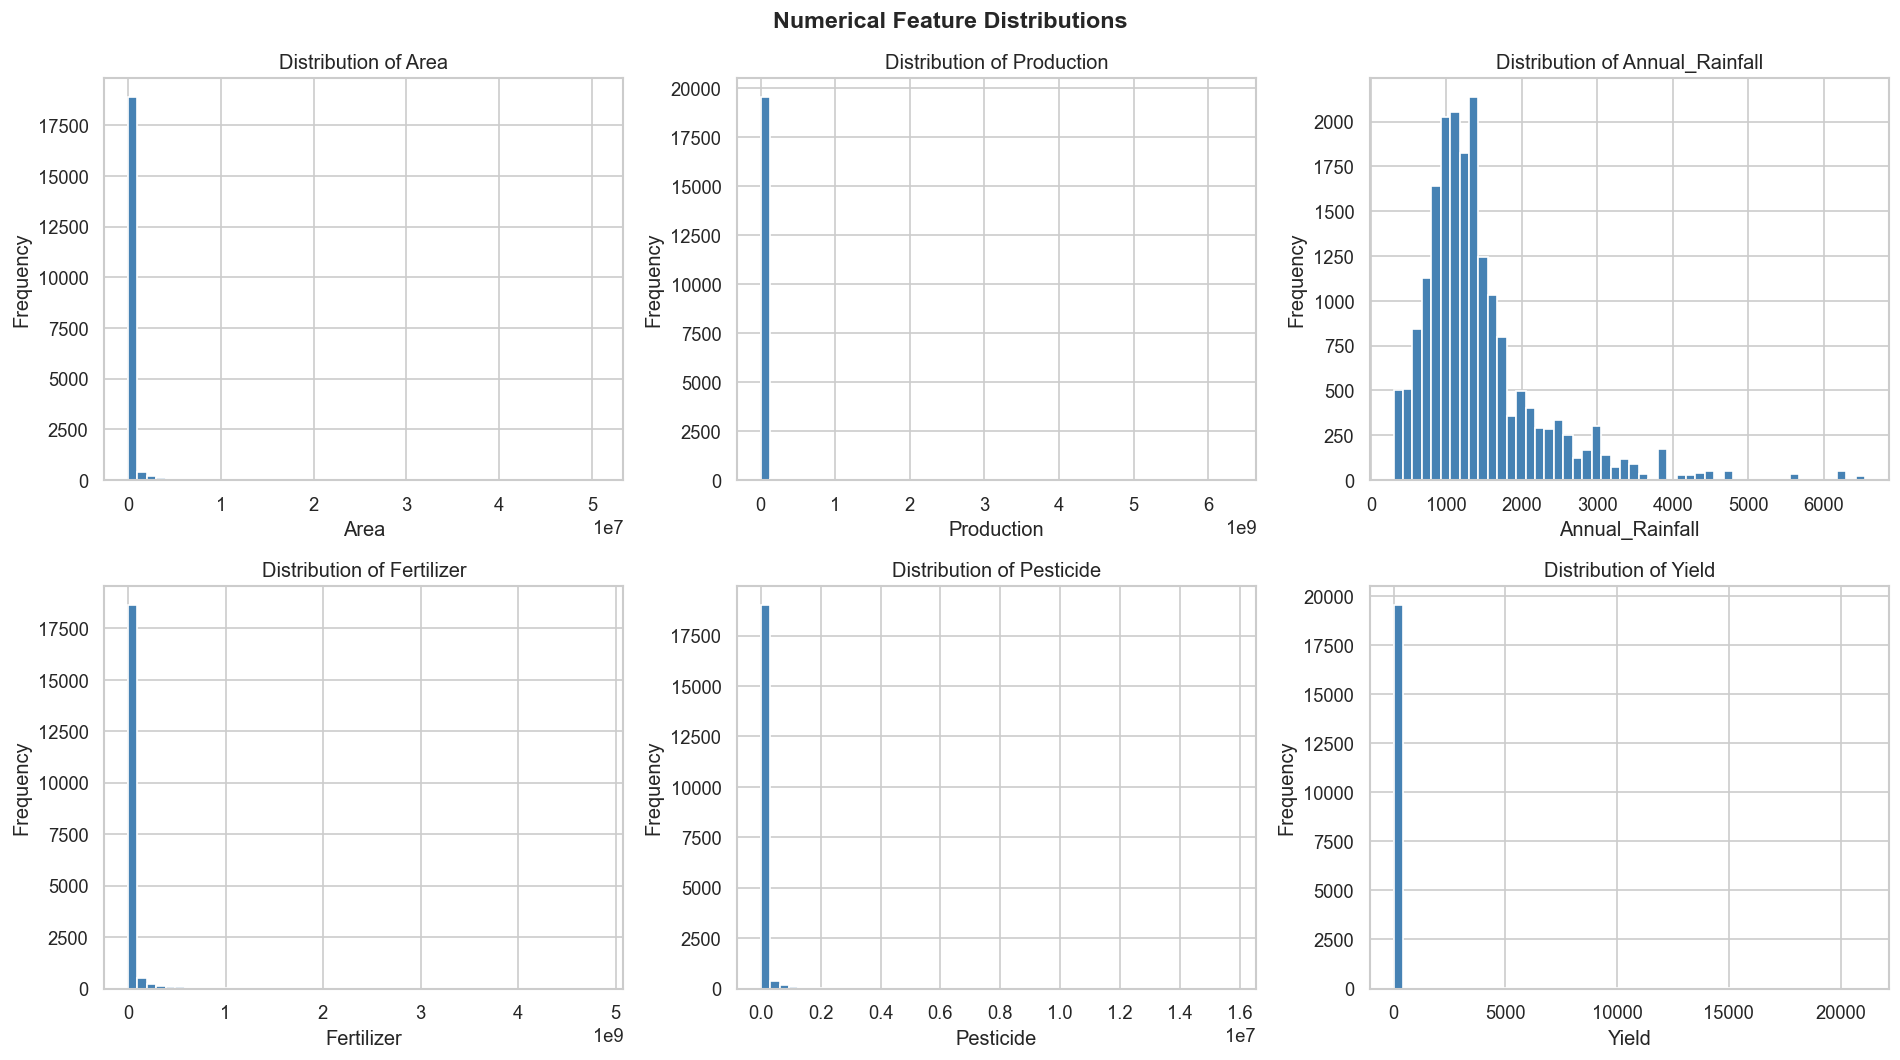

In [10]:
num_cols = ['Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distributions.png')
plt.show()

## 7. Log-Transformed Distributions (Skewness Correction)

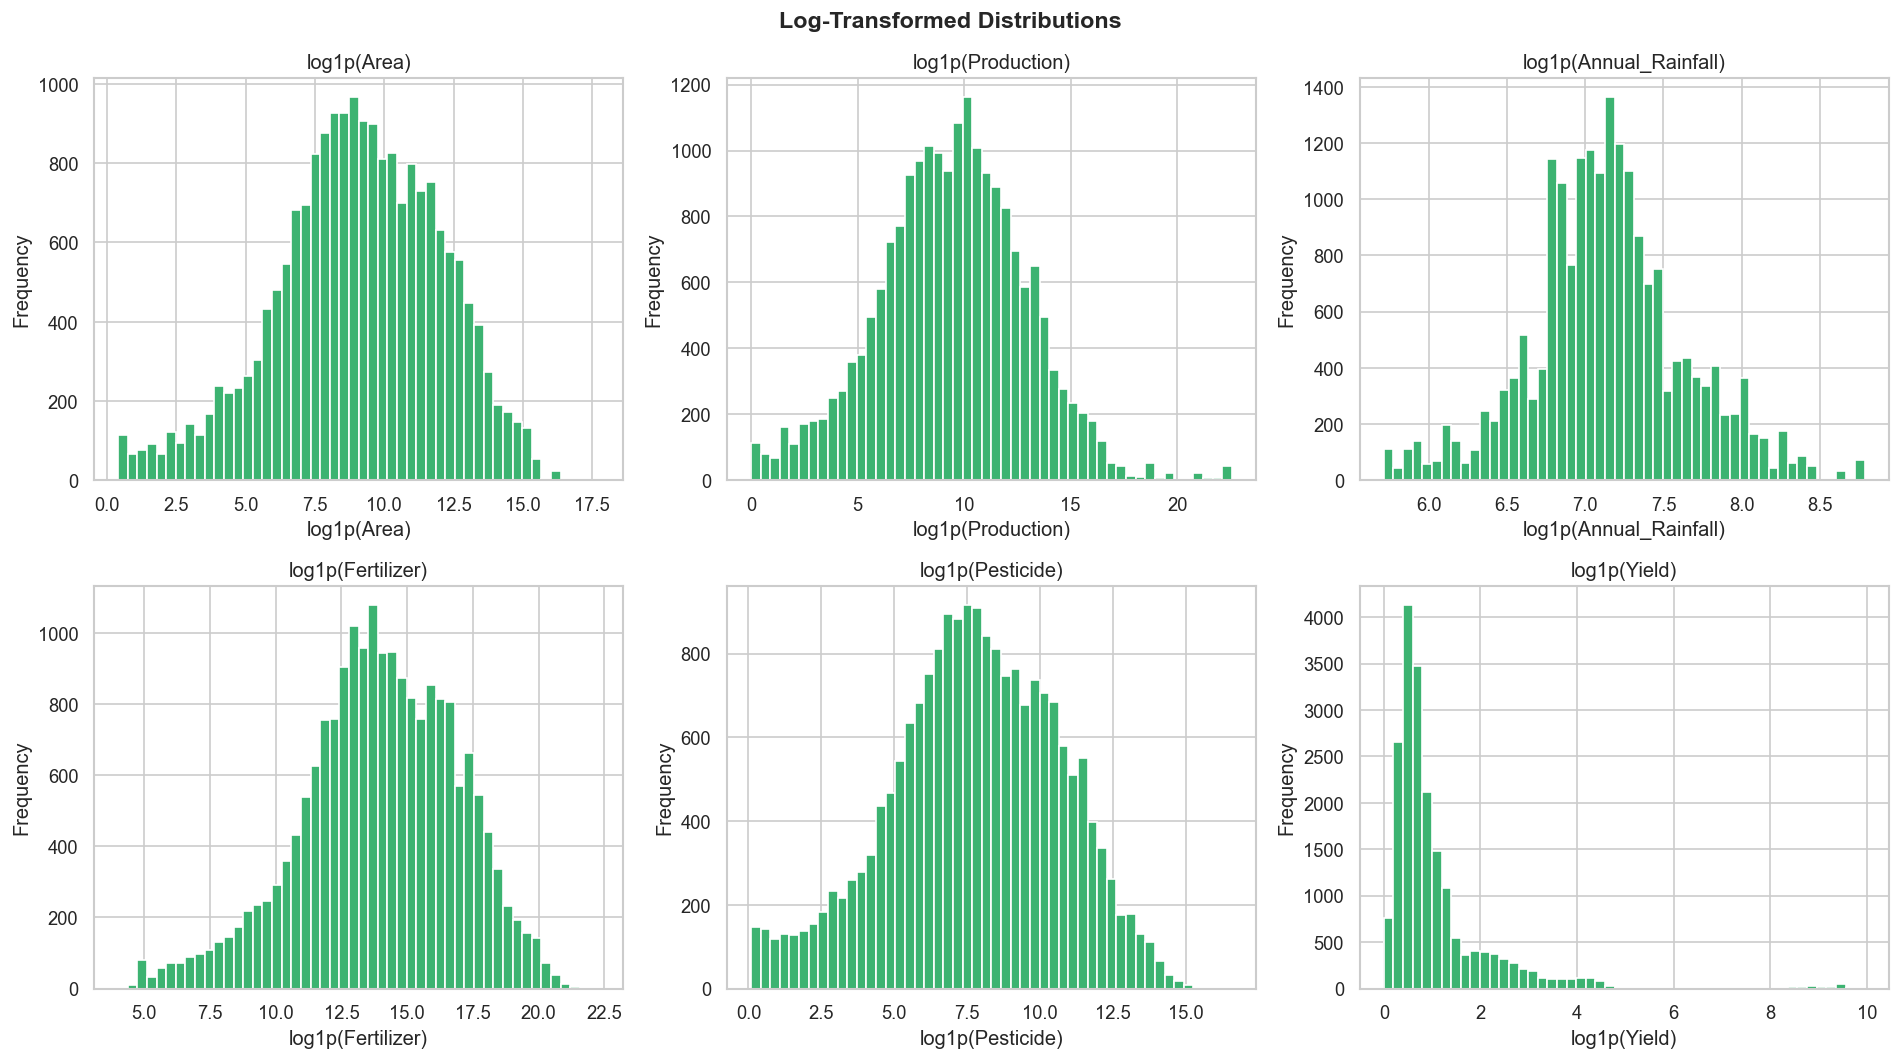

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    log_data = np.log1p(df[col].dropna())
    axes[i].hist(log_data, bins=50, color='mediumseagreen', edgecolor='white')
    axes[i].set_title(f'log1p({col})')
    axes[i].set_xlabel(f'log1p({col})')
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Log-Transformed Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('log_distributions.png')
plt.show()

## 8. Correlation Heatmap

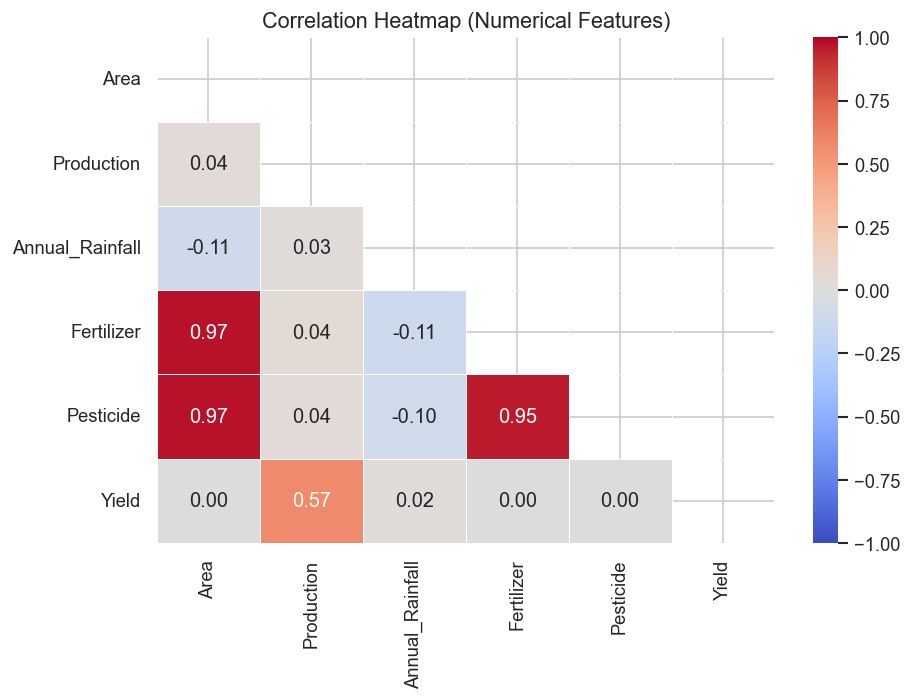

In [12]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap (Numerical Features)', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

## 9. Yield by Season

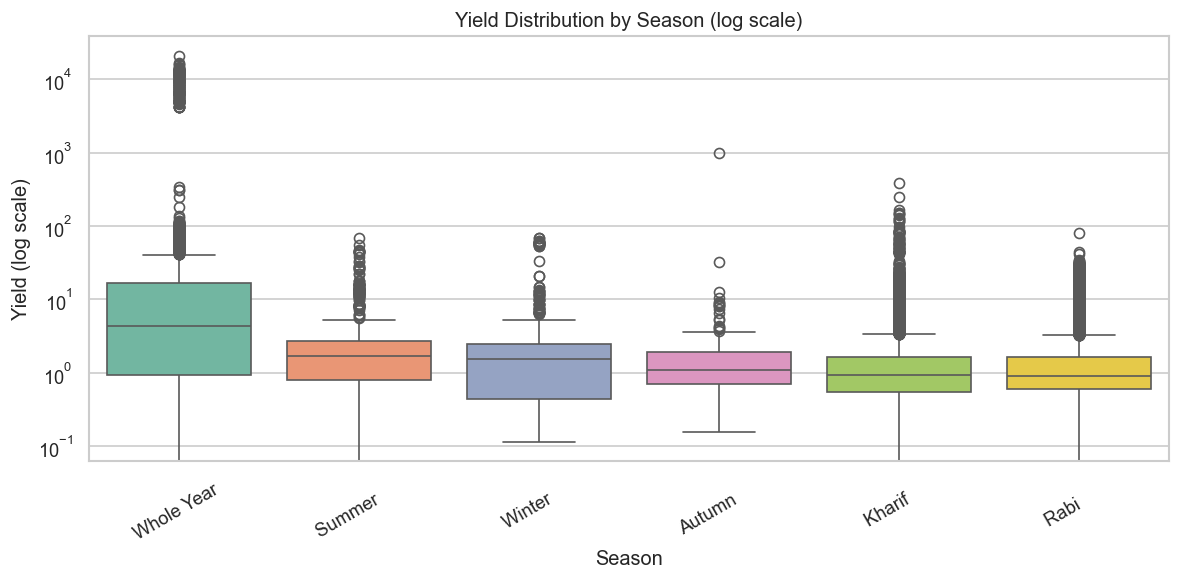

In [13]:
if 'Season' in df.columns and 'Yield' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = df.groupby('Season')['Yield'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='Season', y='Yield', order=order, palette='Set2', ax=ax)
    ax.set_yscale('log')
    ax.set_title('Yield Distribution by Season (log scale)')
    ax.set_xlabel('Season')
    ax.set_ylabel('Yield (log scale)')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig('yield_by_season.png')
    plt.show()

## 10. Top 15 Crops by Average Yield

In [17]:
print(df.groupby('Crop')['Yield'].median().sort_values(ascending=False).head(10))

Crop
Coconut         8466.315523
Sugarcane         53.158158
Banana            17.948750
Tapioca           11.117778
Potato            10.175284
Onion              9.192846
Sweet potato       8.512727
Jute               8.146250
Mesta              4.935250
Ginger             4.887500
Name: Yield, dtype: float64


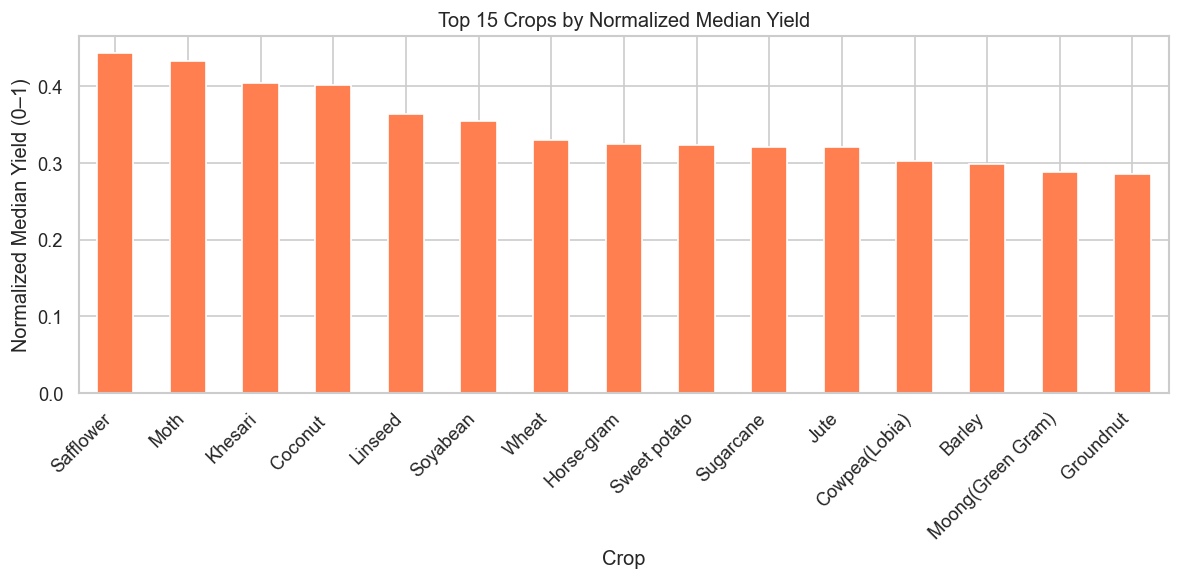

In [18]:
if 'Crop' in df.columns and 'Yield' in df.columns:
    
    # Normalize Yield within each crop (Min-Max Scaling)
    df['Yield_norm'] = df.groupby('Crop')['Yield'].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
    )

    # Compute median of normalized yield
    top_crops = (
        df.groupby('Crop')['Yield_norm']
        .median()
        .sort_values(ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    top_crops.plot(kind='bar', ax=ax, color='coral', edgecolor='white')

    ax.set_title('Top 15 Crops by Normalized Median Yield')
    ax.set_xlabel('Crop')
    ax.set_ylabel('Normalized Median Yield (0–1)')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('top_crops_yield_normalized.png')
    plt.show()

## 11. State-wise Average Yield

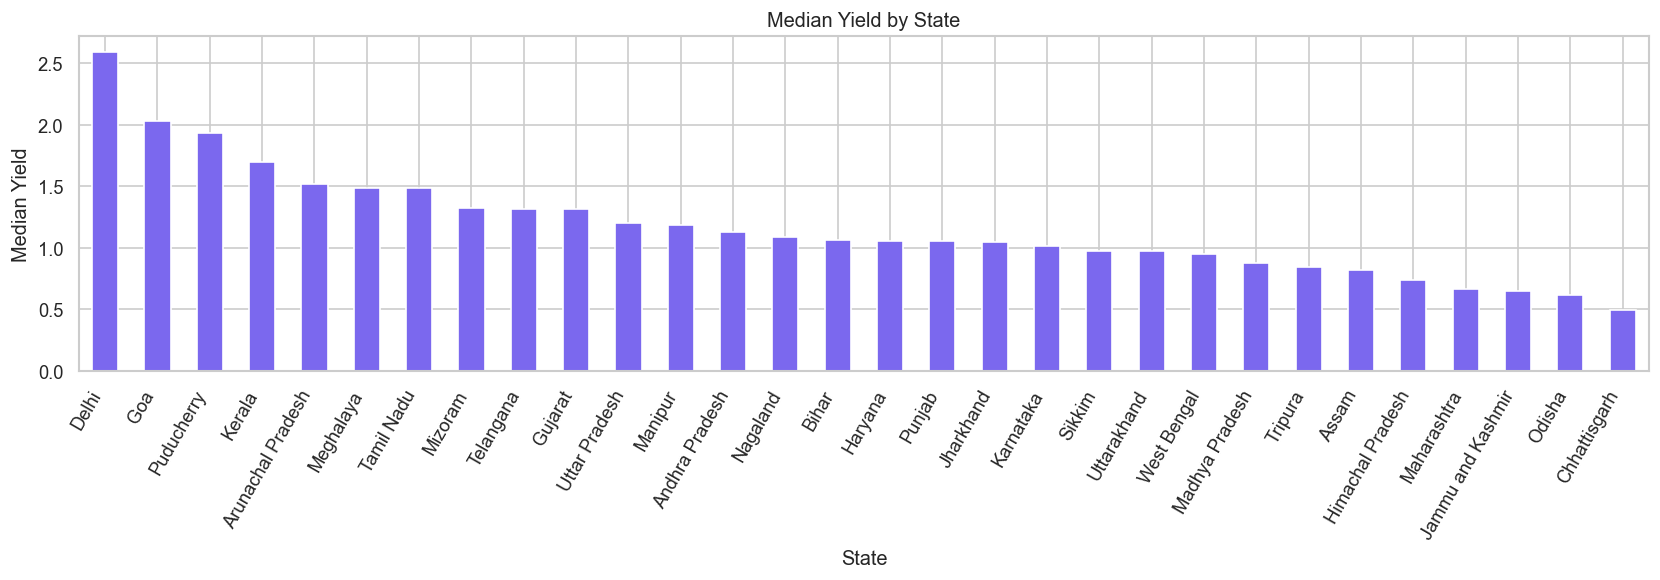

In [19]:
if 'State' in df.columns and 'Yield' in df.columns:
    state_yield = df.groupby('State')['Yield'].median().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(14, 5))
    state_yield.plot(kind='bar', ax=ax, color='mediumslateblue', edgecolor='white')
    ax.set_title('Median Yield by State')
    ax.set_xlabel('State')
    ax.set_ylabel('Median Yield')
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.savefig('state_yield.png')
    plt.show()

## 12. Yield Trend Over Years

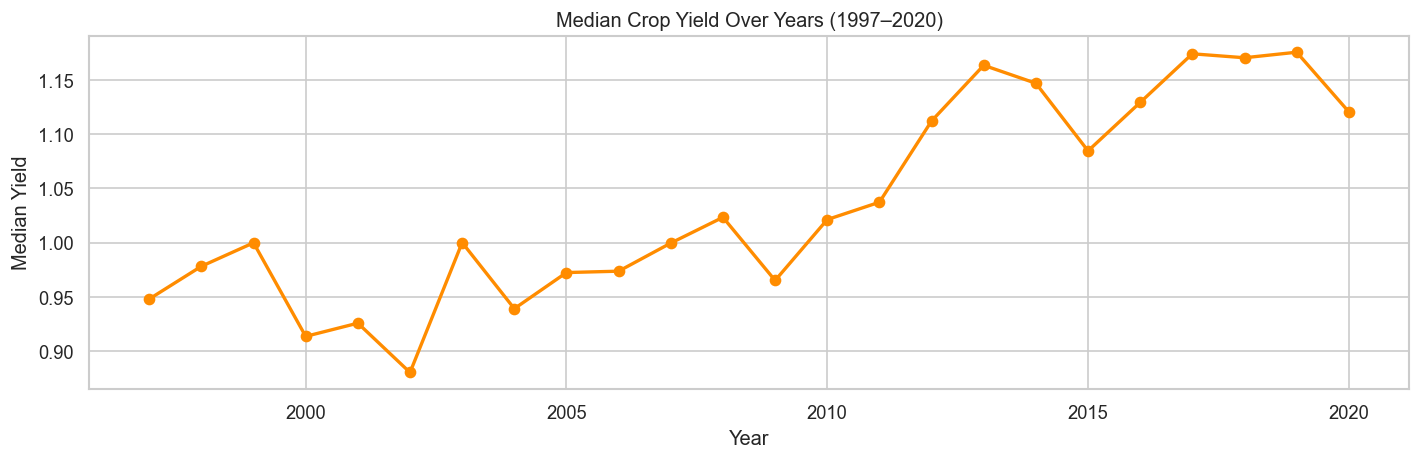

In [20]:
if 'Crop_Year' in df.columns and 'Yield' in df.columns:
    yearly = df.groupby('Crop_Year')['Yield'].median()
    fig, ax = plt.subplots(figsize=(12, 4))
    yearly.plot(ax=ax, marker='o', color='darkorange', linewidth=2)
    ax.set_title('Median Crop Yield Over Years (1997–2020)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Median Yield')
    plt.tight_layout()
    plt.savefig('yield_trend.png')
    plt.show()

## 13. Save Cleaned/Explored Dataset

In [21]:
df.to_csv('crop_eda_output.csv', index=False)
print('EDA output saved to crop_eda_output.csv')
print(f'Final dataset shape: {df.shape}')

EDA output saved to crop_eda_output.csv
Final dataset shape: (19689, 11)
